# Train the best regression model

This small notebook trains the fixed best XGBoost model for predicting `nba_min_3y`, the NBA minutes accumulated in a player's first three seasons. It uses drafted players only, keeps 2020–2022 as the chronological holdout, performs no hyperparameter search, and writes nothing to disk.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "src").is_dir() and (candidate / "configs").is_dir():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the repository.")


REPO_ROOT = find_repo_root(Path.cwd().resolve())
sys.path.insert(0, str(REPO_ROOT / "src"))

from train_model import (
    evaluate,
    load_config,
    load_data,
    make_pipeline,
    prepare_data,
    resolve_path,
    split_data,
)

CONFIG_PATH = REPO_ROOT / "configs/xgboost_minutes_advanced_best.json"

## Load the configured data and make chronological splits

The JSON file is the single source of truth for the feature list, split years, model type, and best hyperparameters.

In [2]:
config = load_config(CONFIG_PATH)
raw_data = load_data(resolve_path(config["data_path"]))
data = prepare_data(raw_data, config)
splits = split_data(data, config["split"])

target = config["target"]
year_column = config["split"]["column"]
features = config["numerical_features"] + config["categorical_features"]

split_rows = []
for name, frame in splits.items():
    split_rows.append({
        "split": name,
        "rows": len(frame),
        "first_year": int(frame[year_column].min()),
        "last_year": int(frame[year_column].max()),
        "mean_minutes": frame[target].mean(),
        "missing_feature_cells": int(frame[features].isna().sum().sum()),
    })

print(f"Rows retained: {len(data):,} of {len(raw_data):,}")
print(f"Configured features: {len(features)}")
display(pd.DataFrame(split_rows).set_index("split").round(2))
display(pd.Series(config["model"]["hyperparameters"], name="value").to_frame())

Rows retained: 838 of 838
Configured features: 48


,rows,first_year,last_year,mean_minutes,missing_feature_cells
split,,,,,
train,540,2009,2017,2290.79,4906
validation,120,2018,2019,2412.35,785
test,178,2020,2022,2479.57,1422


,value
objective,reg:squarederror
tree_method,hist
random_state,42
n_jobs,-1
n_estimators,500
learning_rate,0.02
max_depth,1
min_child_weight,10
subsample,1.0
colsample_bytree,0.8


## What is preprocessed

The processed Parquet table already contains the engineered predictors. They include nonlinear draft-pick transforms, age terms, age-by-pick interactions, last-season and career college production, changes from career to the last season, and compact shooting, playmaking, and production composites.

The training code converts configured numerical columns to numbers, replaces infinite values with missing values, then learns median replacements and standardization from the fitted rows only. The target is not log-transformed in this best configuration. The shallow, strongly regularized XGBoost settings shown above are used exactly as stored in the JSON file.

## Train once with the best hyperparameters

The winning settings were selected before the test years were scored. As configured, the final model is fitted on train plus validation; therefore only the test row below is an out-of-time holdout result.

In [3]:
model = make_pipeline(config)
fit_data = splits["train"]
if config.get("refit_on_train_validation", False):
    fit_data = pd.concat([splits["train"], splits["validation"]], ignore_index=True)

model.fit(fit_data[features], fit_data[target])
metrics = pd.DataFrame(evaluate(model, splits, features, target)).T

print(f"Fitted rows: {len(fit_data):,}")
display(metrics[["rows", "rmse", "r2"]].round(3))

Fitted rows: 660


,rows,rmse,r2
train,540.0,1443.149,0.574
validation,120.0,1311.385,0.557
test,178.0,1568.183,0.482


## Holdout predictions

The diagonal is perfect prediction. Distance from it shows how far a player's predicted opportunity was from his observed first-three-season minutes.

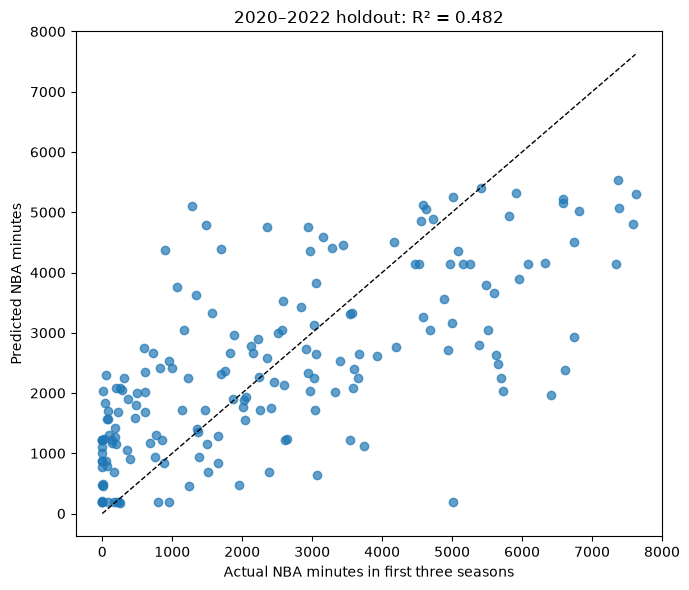

Largest holdout errors:


,PLAYER_NAME,draft_year,nba_min_3y,prediction,residual,absolute_error
711,KJ Martin,2020,5016.1,192.600006,4823.6,4823.6
757,Ayo Dosunmu,2021,6419.7,1975.400024,4444.3,4444.3
754,Herbert Jones,2021,6607.1,2388.800049,4218.3,4218.3
789,Johnny Davis,2022,1277.7,5101.100098,-3823.4,3823.4
678,Saddiq Bey,2020,6741.9,2929.800049,3812.1,3812.1
687,Jaden McDaniels,2020,5729.9,2033.099976,3696.9,3696.9
730,James Bouknight,2021,900.8,4370.799805,-3470.0,3470.0
735,Alperen Sengun,2021,5705.6,2242.899902,3462.7,3462.7
672,Kira Lewis Jr.,2020,1480.4,4789.200195,-3308.9,3308.9
721,Jalen Green,2021,7341.3,4139.899902,3201.4,3201.4


In [4]:
test = splits["test"]
test_results = test[[year_column, target]].copy()
identity = next(
    (column for column in ["player_name", "PLAYER_NAME", "nba_player_id"] if column in test),
    None,
)
if identity is not None:
    test_results.insert(0, identity, test[identity])
test_results["prediction"] = model.predict(test[features])
test_results["residual"] = test_results[target] - test_results["prediction"]
test_results["absolute_error"] = test_results["residual"].abs()

lower = float(min(test_results[target].min(), test_results["prediction"].min()))
upper = float(max(test_results[target].max(), test_results["prediction"].max()))
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(test_results[target], test_results["prediction"], alpha=0.7)
ax.plot([lower, upper], [lower, upper], "--", color="black", linewidth=1)
ax.set(
    title=f"2020–2022 holdout: R² = {metrics.loc['test', 'r2']:.3f}",
    xlabel="Actual NBA minutes in first three seasons",
    ylabel="Predicted NBA minutes",
)
plt.tight_layout()
plt.show()

print("Largest holdout errors:")
display(test_results.nlargest(10, "absolute_error").round(1))

### How to interpret this model

This is conditional on a player already being drafted. In particular, `overall_pick` is known only after the draft and summarizes team investment as well as player evaluation. The model predicts early opportunity, not whether a prospect will be drafted and not a causal effect of any feature. Large errors remain, and the 2020–2022 holdout should not be reused to choose new features or hyperparameters.